In [2]:
import matplotlib.pyplot as plt
import numpy as np

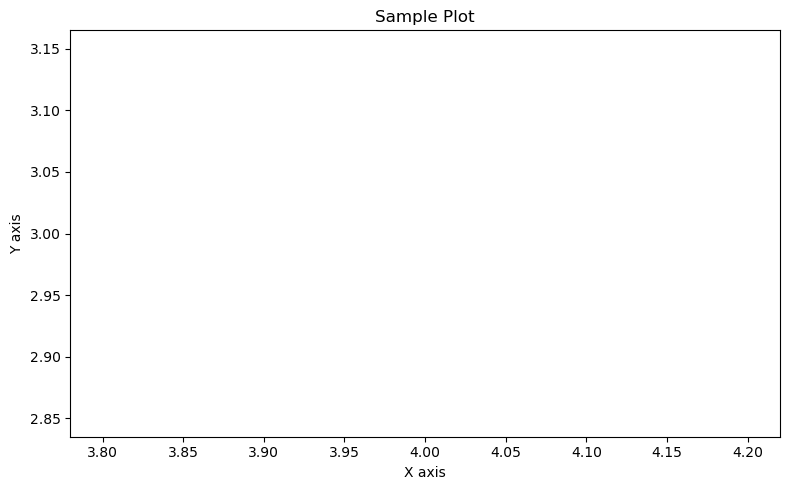

In [4]:
# x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
# y = np.array([19, 18, 17, 16, 15, 14, 13])

# 1. Create the figure and axes
fig, ax = plt.subplots(figsize = (8, 5))

# 2. Plot data on the axes
ax.plot(4, 3)

# 3. Dress the chart (labels, title, grid)
ax.set_title("Sample Plot")
ax.set_xlabel("X axis");ax.set_ylabel("Y axis")

plt.tight_layout()
plt.show()

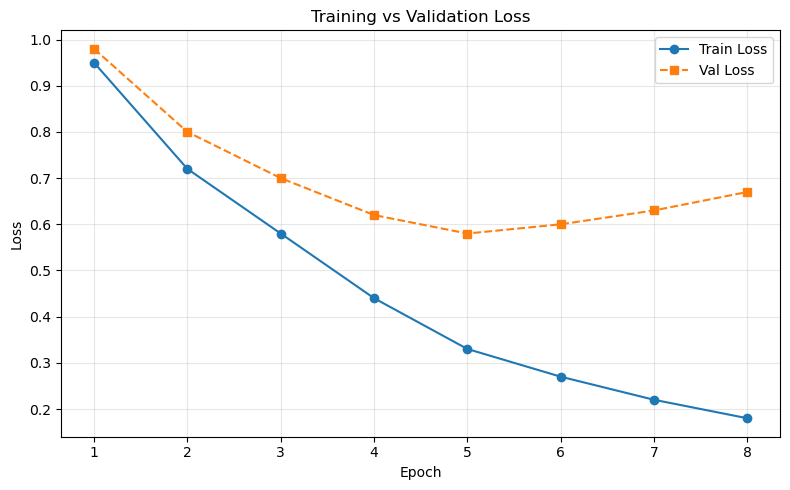

In [6]:
train_loss = [0.95, 0.72, 0.58, 0.44, 0.33, 0.27, 0.22, 0.18]
val_loss   = [0.98, 0.80, 0.70, 0.62, 0.58, 0.60, 0.63, 0.67]
epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(figsize = (8, 5))

ax.plot(epochs, train_loss, label = "Train Loss", marker = "o")
ax.plot(epochs, val_loss, label = "Val Loss", marker = "s", linestyle = "--")

ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

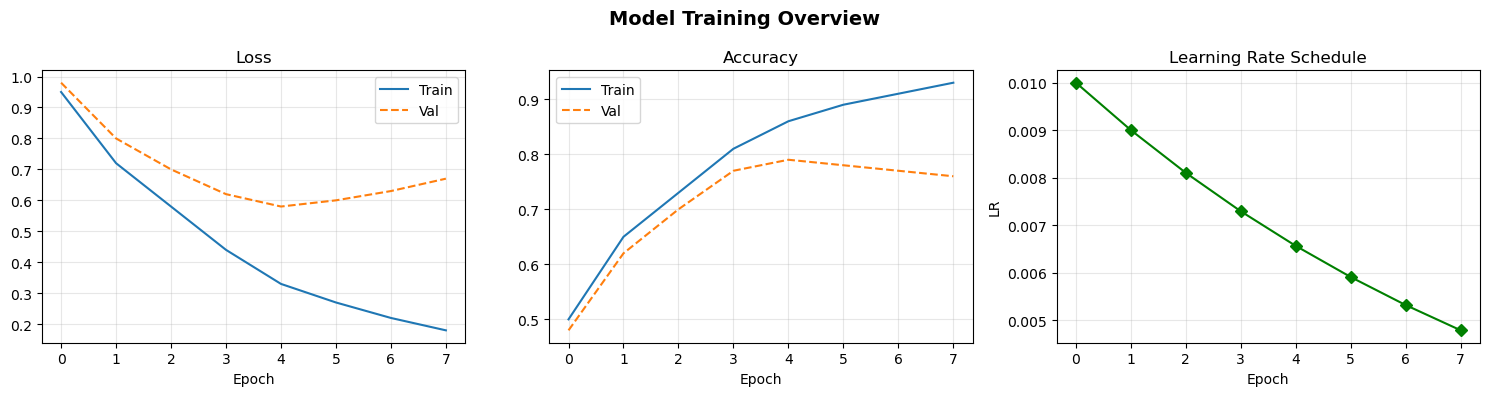

In [8]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

# Plot 1 - loss
axes[0].plot(train_loss, label = "Train")
axes[0].plot(val_loss, label = "Val", linestyle = "--")
axes[0].set_title("Loss")
axes[0].legend()

# Plot 2 - accuracy
train_acc = [0.50, 0.65, 0.73, 0.81, 0.86, 0.89, 0.91, 0.93]
val_acc   = [0.48, 0.62, 0.70, 0.77, 0.79, 0.78, 0.77, 0.76]

axes[1].plot(train_acc, label = "Train")
axes[1].plot(val_acc, label = "Val", linestyle = "--")
axes[1].set_title("Accuracy")
axes[1].legend()

# Plot 3 - Learning Rate Schedule
lrs = [0.01 * (0.9 **i) for i in range(8)]
axes[2].plot(lrs, color = "green", marker = "D")
axes[2].set_title("Learning Rate Schedule")
axes[2].set_ylabel("LR")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha = 0.3)

plt.suptitle("Model Training Overview", fontsize = 14, fontweight = "bold")
plt.tight_layout()
plt.savefig("Comparison Plot.png", dpi = 150)
plt.show()


## 1. EDA 

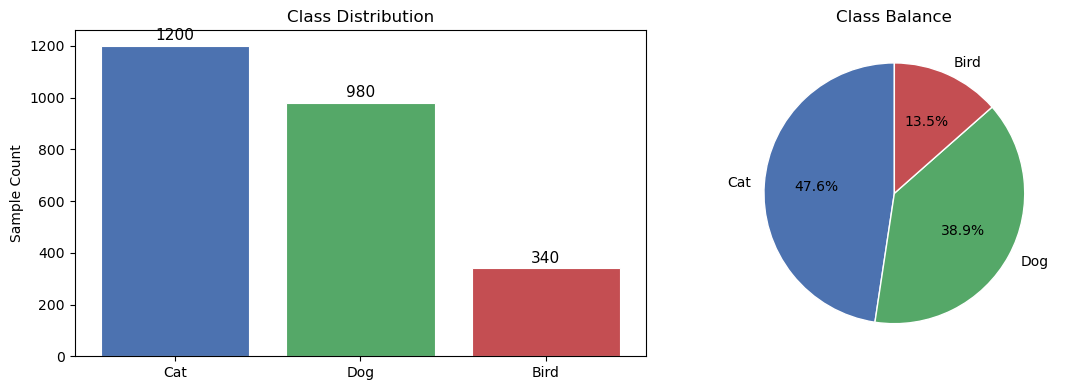

In [14]:
labels = ['Cat', 'Dog', 'Bird']
counts = [1200, 980, 340]
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

bars = axes[0].bar(labels, counts, color = colors, edgecolor = "white", linewidth = 0.8)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Sample Count")
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(count), ha = "center", va = 'bottom', fontsize = 11)

axes[1].pie(counts, labels = labels, colors = colors, autopct = '%1.1f%%', startangle = 90, wedgeprops = {'edgecolor' : 'white'})
axes[1].set_title("Class Balance")

plt.tight_layout()
plt.show()

## 2. Feature Distributions (histograms + KDE)

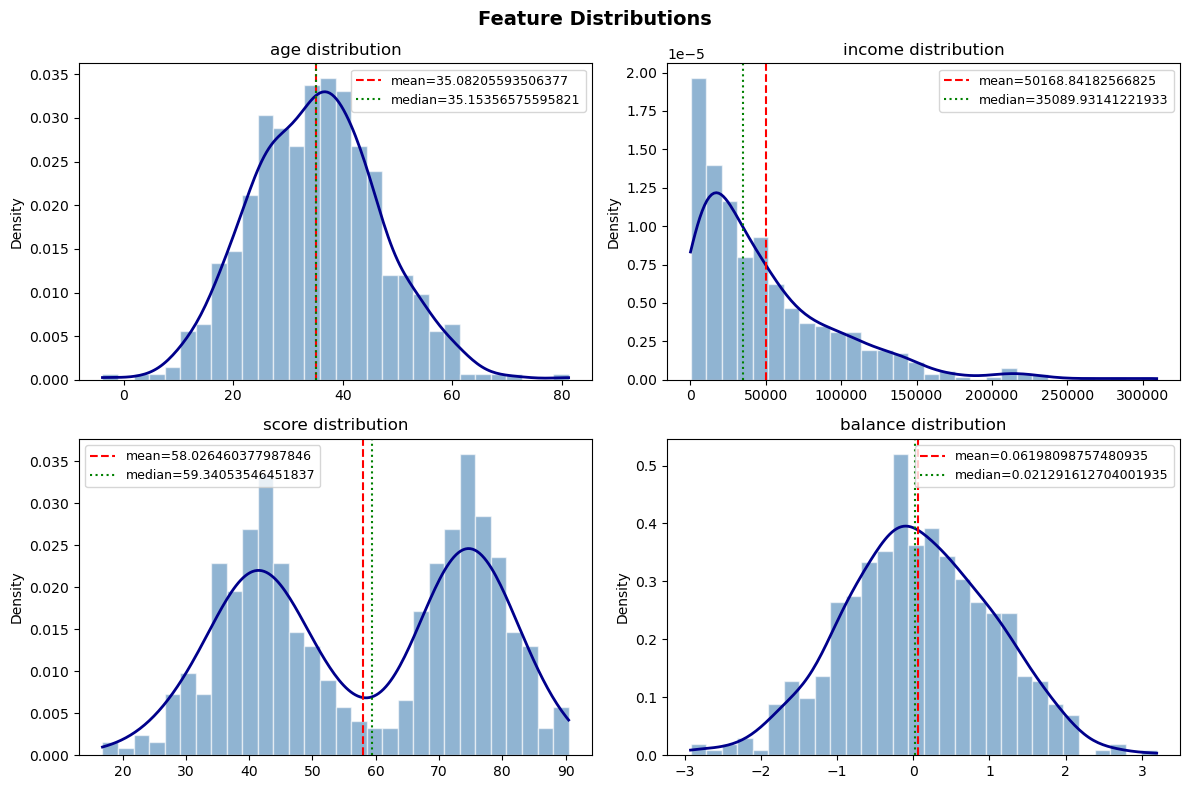

In [17]:
from scipy.stats import gaussian_kde

np.random.seed(42)
features = {
    'age': np.random.normal(35, 12, 500),
    'income': np.random.exponential(50000, 500),
    'score': np.concatenate([np.random.normal(40, 8, 250), np.random.normal(75, 6, 250)]),
    'balance': np.random.normal(0, 1, 500)
}

fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for ax, (name, data) in zip(axes, features.items()):
    ax.hist(data, bins = 30, color = 'steelblue', alpha = 0.6, density = True, edgecolor = 'white')

    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, kde(x), color = 'darkblue', linewidth = 2)

    ax.axvline(data.mean(), color = 'red', linestyle = "--", label = f'mean={data.mean()}')
    ax.axvline(np.median(data), color = 'green', linestyle = ":", label = f'median={np.median(data)}')

    ax.set_title(f'{name} distribution')
    ax.legend(fontsize = 9)
    ax.set_ylabel("Density")

plt.suptitle("Feature Distributions", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

## 3. Outlier Detection with boxplots

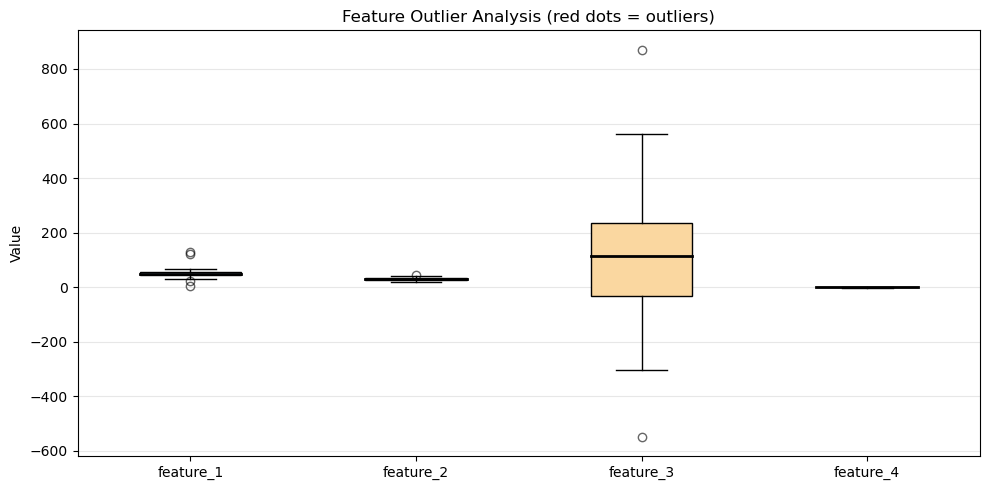

In [19]:
np.random.seed(42)
data = {
    'feature_1': np.append(np.random.normal(50, 10, 100), [5, 120, 130]),
    'feature_2': np.random.normal(30, 5, 103),
    'feature_3': np.append(np.random.normal(100, 200, 100), [200, 210, -10]),
    'feature_4': np.random.normal(0, 1, 103)
}

fig, ax = plt.subplots(figsize = (10, 5))

bp = ax.boxplot(data.values(), labels = data.keys(), patch_artist = True, medianprops = {'color': 'black', 'linewidth': 2}, flierprops = {'marker': 'o', 'color': 'red', 'markersize': 6, 'alpha': 0.6})

colors = ['#AED6F1', '#A9DFBF', '#FAD7A0', '#D2B4DE']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title("Feature Outlier Analysis (red dots = outliers)")
ax.set_ylabel("Value")
ax.grid(axis = 'y', alpha = 0.3)
plt.tight_layout()
plt.show()

## 4. Loss and Accuracy Curves

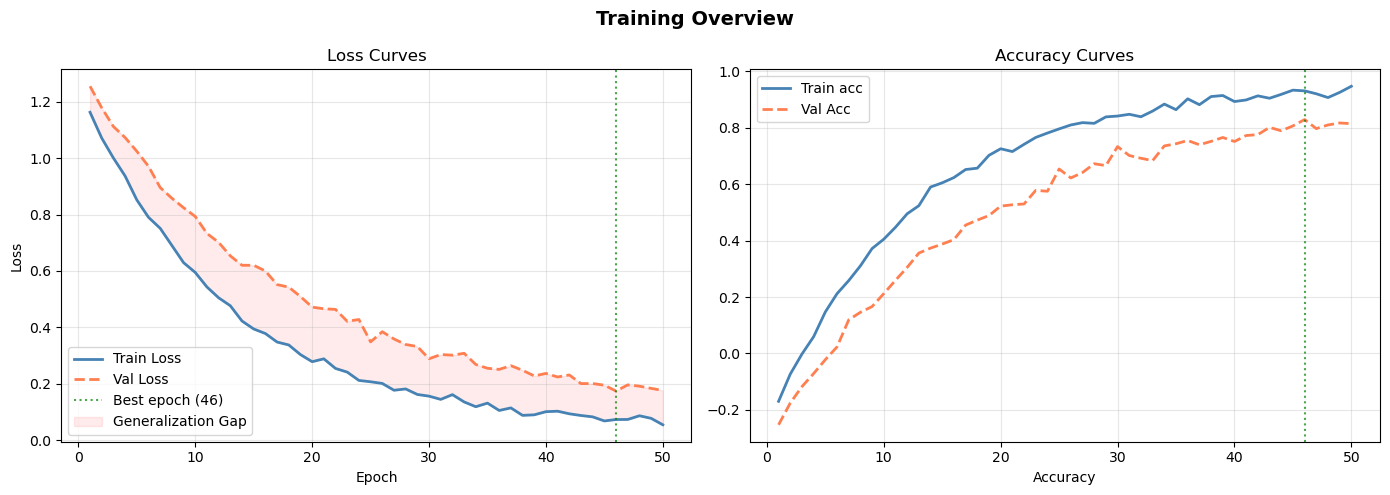

In [23]:
np.random.seed(42)
epochs = range(1, 51)

train_loss = [1.2 * np.exp(-0.08*e) + 0.05 + np.random.normal(0, 0.01) for e in epochs]
val_loss   = [1.2 * np.exp(-0.06*e) + 0.12 + np.random.normal(0, 0.015) for e in epochs]
train_acc  = [1 - tl + np.random.normal(0, 0.005) for tl in train_loss]
val_acc    = [1 - vl + np.random.normal(0, 0.008) for vl in val_loss]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

ax1.plot(epochs, train_loss, label = 'Train Loss', color = 'steelblue', linewidth = 2)
ax1.plot(epochs, val_loss, label = 'Val Loss', color = 'coral', linewidth = 2, linestyle = '--')

best_epoch = int(np.argmin(val_loss)) + 1

ax1.axvline(best_epoch, color = 'green', linestyle = ':', alpha = 0.7, label = f'Best epoch ({best_epoch})')
ax1.fill_between(epochs, train_loss, val_loss, alpha = 0.08, color = 'red', label = "Generalization Gap")

ax1.set_title("Loss Curves")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha = 0.3)

ax2.plot(epochs, train_acc, label = 'Train acc', color = 'steelblue', linewidth = 2)
ax2.plot(epochs, val_acc, label = 'Val Acc', color = 'coral', linewidth = 2, linestyle = '--')
ax2.axvline(best_epoch, color = 'green', linestyle = ":", alpha = 0.7)
ax2.set_title("Accuracy Curves")
ax2.set_xlabel("Accuracy")
ax2.legend()
ax2.grid(alpha = 0.3)

plt.suptitle("Training Overview", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

## 5. Learning Rate Schedule

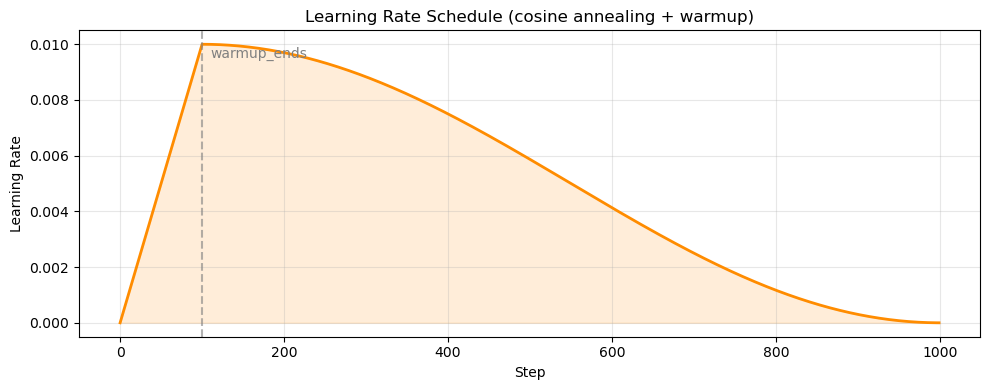

In [25]:
total_steps = 1000
warmup_steps = 100

def cosine_with_warmup(step, warmup = 100, total = 1000, lr_max = 0.01):
    if step < warmup:
        return lr_max * step / warmup
    progress = (step - warmup) / (total - warmup)
    return lr_max * 0.5 * (1 + np.cos(np.pi * progress))

steps = np.arange(total_steps)
lrs = [cosine_with_warmup(s) for s in steps]

fig, ax = plt.subplots(figsize = (10, 4))
ax.plot(steps, lrs, color = 'darkorange', linewidth = 2)

ax.axvline(warmup_steps, color = 'gray', linestyle = '--', alpha = 0.6)
ax.text(warmup_steps + 10, max(lrs) * 0.95, 'warmup_ends', color = 'gray', fontsize = 10)

ax.fill_between(steps, lrs, alpha = 0.15, color = 'darkorange')
ax.set_title("Learning Rate Schedule (cosine annealing + warmup)")
ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

## 6. Confusion Matrix

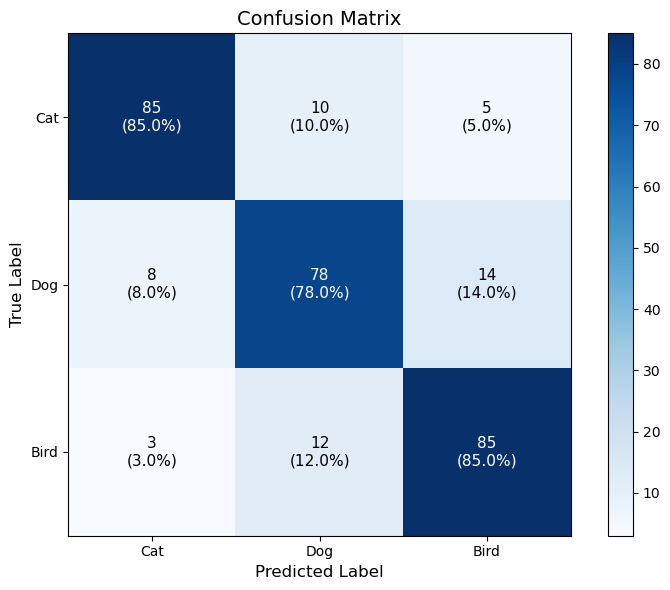

In [28]:
def plot_confusion_matrix(cm, class_names):

    fig, ax = plt.subplots(figsize = (8,6))

    im = ax.imshow(cm, interpolation = 'nearest', cmap = 'Blues')
    plt.colorbar(im, ax = ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted Label', fontsize = 12)
    ax.set_ylabel('True Label', fontsize = 12)
    ax.set_title('Confusion Matrix', fontsize = 14)

    total = cm.sum(axis = 1, keepdims = True)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            pct = cm[i, j] / total[i, 0] * 100
            color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
            ax.text(j, i, f'{cm[i, j]}\n({pct:.1f}%)', ha = 'center', va = 'center', color = color, fontsize = 11)

    plt.tight_layout()
    plt.show()

cm = np.array([[85, 10, 5], [8, 78, 14], [3, 12, 85]])
plot_confusion_matrix(cm, ['Cat', 'Dog', 'Bird'])

# Seaborn

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(
    style="whitegrid",     # whitegrid | darkgrid | white | dark | ticks
    palette="tab10",       # tab10 | deep | muted | pastel | Set2 | husl
    font_scale=1.1         # scales all text uniformly
)

# Override figure size globally (optional)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

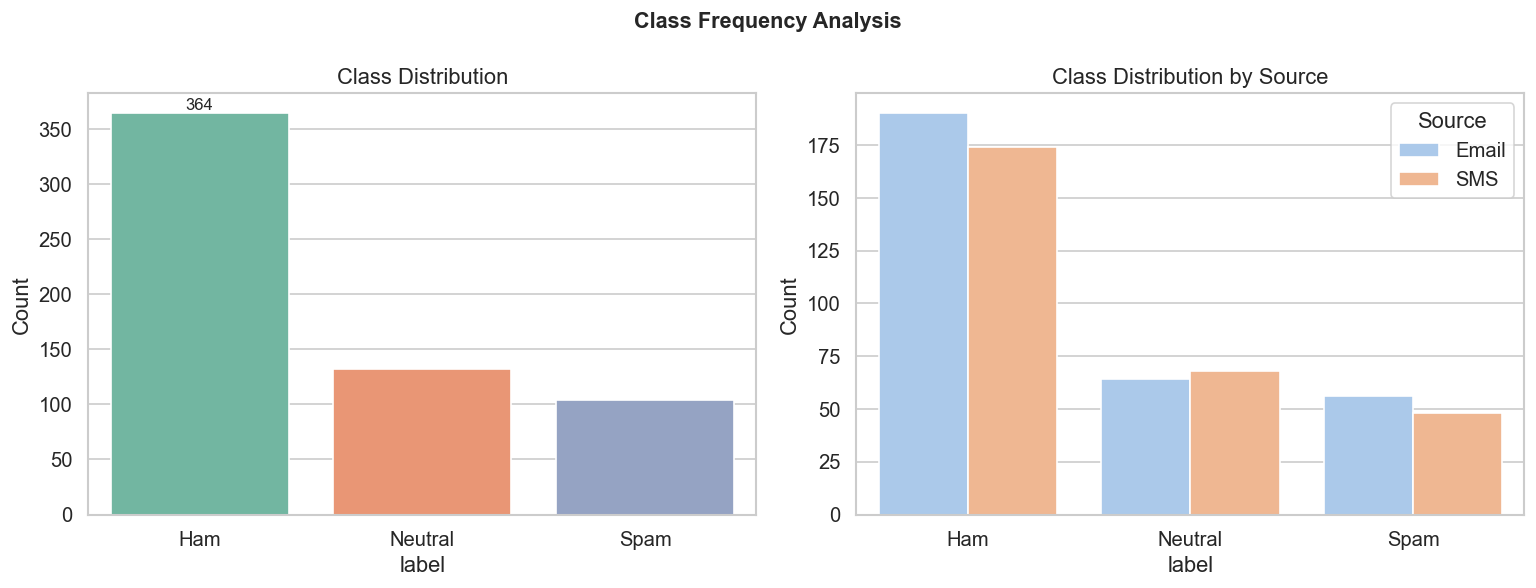

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [31]:
np.random.seed(42)

df = pd.DataFrame({
    'label':  np.random.choice(['Spam', 'Ham', 'Neutral'], size=600,
                                p=[0.15, 0.65, 0.20]),
    'source': np.random.choice(['Email', 'SMS'], size=600)
})

fig, axes = plt.subplots(1, 2, figsize = (13, 5))

sns.countplot(data = df, x = 'label', order = df['label'].value_counts().index, palette = 'Set2', ax = axes[0])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height() + 3), ha = 'center', fontsize = 10)

    sns.countplot(data = df, x = 'label', hue = 'source', order = df['label'].value_counts().index, palette = 'pastel', ax = axes[1])

    axes[1].set_title("Class Distribution by Source")
    axes[1].set_ylabel("Count")
    axes[1].legend(title = 'Source')

    plt.suptitle("Class Frequency Analysis", fontsize = 13, fontweight = 'bold')
    plt.tight_layout()
    plt.show()